## Importing the Library

In [40]:
from Image_analysis_class_week13 import ImageAnalyzer

## Importing your image, converting it to grayscale and printing it

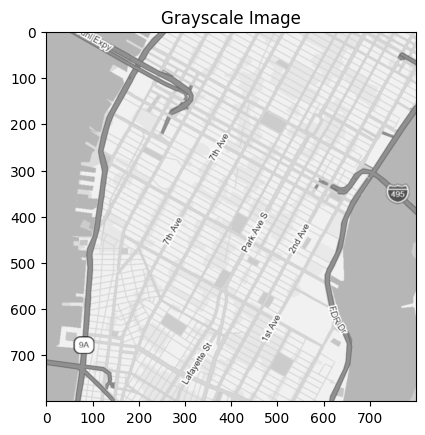

In [41]:
imagefile = r'Images\NYC.webp'


img = ImageAnalyzer.load_crop_grayscale(imagefile, [200, 1000, 300, 1100])

ImageAnalyzer.plot_image(img)

## Chose your $\sigma$ values, and compute structure tensor values

In [42]:
sigma_derivative = 1
sigma_tensor = 2

# Ix, Iy = ImageAnalyzer.compute_gradients(img, sigma_deriv=sigma_derivative)

# S11, S12, S22 = ImageAnalyzer.structure_tensor(Ix, Iy)

# S11, S12, S22 = ImageAnalyzer.smooth_tensor(S11, S12, S22, sigma_tensor=sigma_tensor)

## create your structure tensor, find its eigen values and vectors, and find the angle of dominant orientation for each structure tensor 

In [43]:
# S = ImageAnalyzer.tensor_to_matrix(S11, S12, S22)

S = ImageAnalyzer.compute_structure_tensor(img, sigma_derivative, sigma_tensor)
evals, evecs = ImageAnalyzer.eigendecomposition(S)

lam_s, lam_l, v_s, v_l = ImageAnalyzer.split_eigenpairs(evals, evecs)

theta = ImageAnalyzer.orientation_from_eigenvectors(v_s)

# vx, vy = ImageAnalyzer.orientation_to_unit_vectors(theta)

##  Orientation vectors

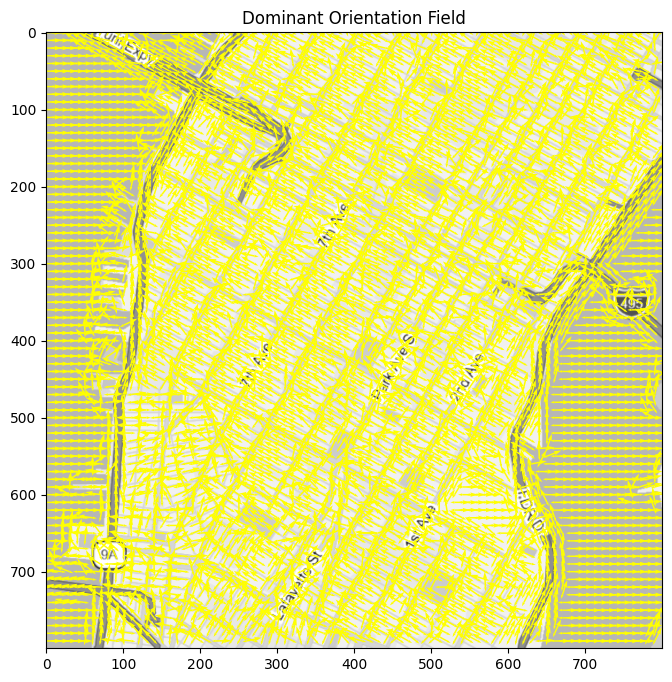

In [57]:
ImageAnalyzer.plot_orientation_vectors(img, S, step = 10, scale = 40)

## chose energy cutoff, compute energy, isotropy, anisotropy, create an energy mask and apply the mask 

In [45]:
percent = 45

# energy = ImageAnalyzer.compute_energy(lam_s, lam_l)

# aniso = ImageAnalyzer.compute_isotropy_anisotropy(lam_s, lam_l)

# mask = ImageAnalyzer.energy_mask(energy, percent)

# aniso_masked = ImageAnalyzer.mask_anisotropy(aniso, mask)

aniso_masked = ImageAnalyzer.compute_anisotropy_masked(S)


## Visualize dominant orientatioin on orignal picture with defined energy cutoff

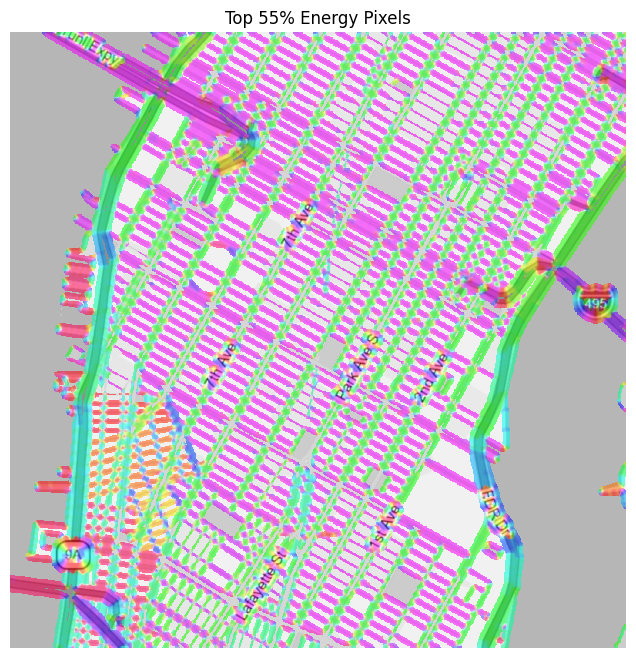

In [46]:
ImageAnalyzer.plot_orientation_overlay(
    img,
    theta,
    aniso_masked,
    percent
)

## computing values counts and bins for histogram

In [47]:
counts, centers, width = ImageAnalyzer.compute_orientation_histogram(
    theta,
    aniso_masked,
    bins=180
)


## Plotting the orientational Histogram 

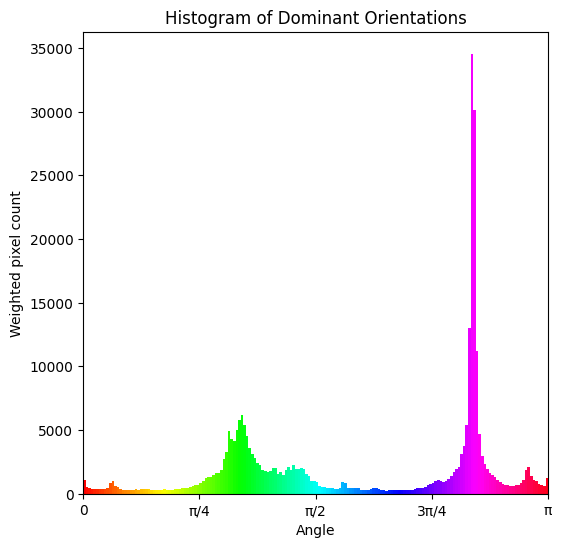

In [48]:

ImageAnalyzer.plot_orientation_histogram(counts, centers, width)

## Plot Polar Histogram

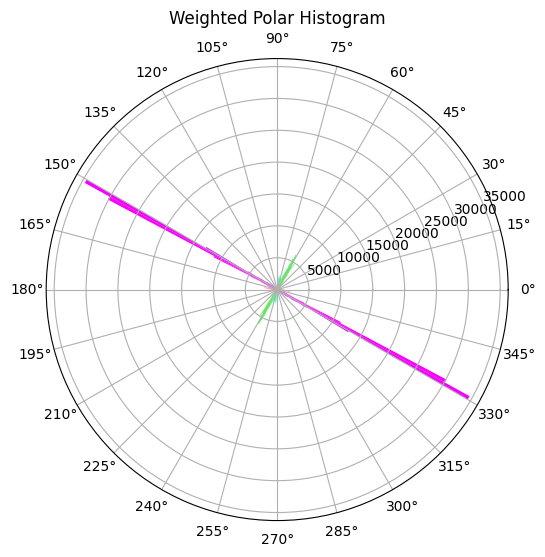

In [49]:
ImageAnalyzer.plot_polar_histogram(
    counts, centers, width
)

## Chose Dominant orientations, and compute the binned angles to include

In [50]:
# Define dominant orientations and tolerance 
centers = [55, 145]
tolerance_deg=10

chosen_theta = ImageAnalyzer.bin_orientations(theta, centers, tolerance_deg)

## Plot grouped Dominant Orientations

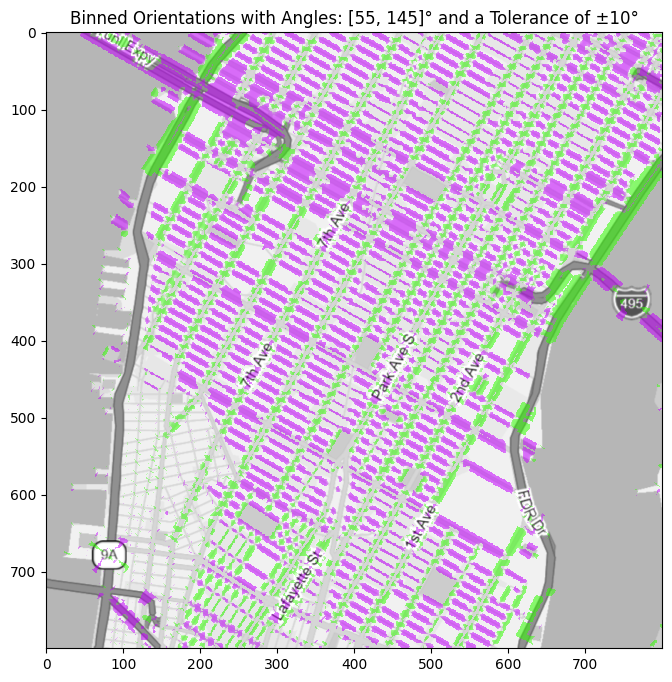

In [51]:

ImageAnalyzer.plot_binned_orientations(
    img,
    chosen_theta,
    aniso_masked,
    centers,
    tolerance_deg
)

## computing Orientationally grouped Histogram

In [52]:
grouped_counts, grouped_bin_centers, grouped_bin_width = ImageAnalyzer.compute_orientation_histogram(chosen_theta, aniso_masked)

## Plotting Orientationally grouped Histogram

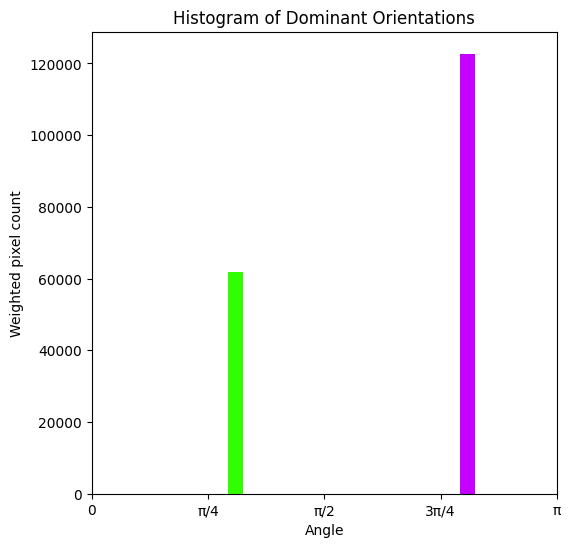

In [53]:
ImageAnalyzer.plot_orientation_histogram(grouped_counts, grouped_bin_centers, 0.1)

## Plotting Orientationally grouped Polar Histogram

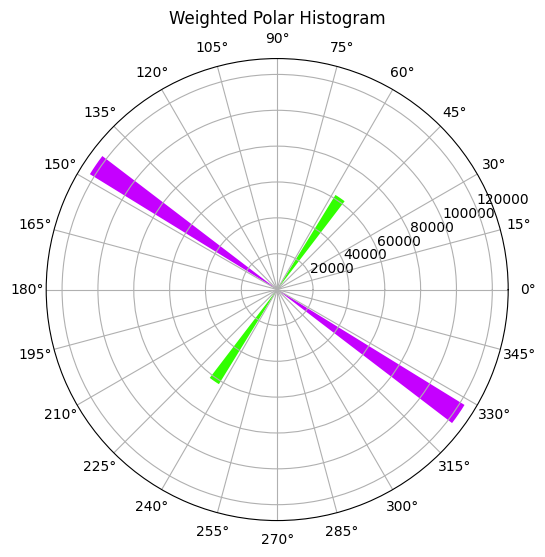

In [54]:
ImageAnalyzer.plot_polar_histogram(grouped_counts, grouped_bin_centers, 0.1)

## Calculating a Organic pertentile

In [55]:
percentile = ImageAnalyzer.compute_alignment_percentage(
    theta,
    aniso_masked,
    centers,
    tolerance_deg=10
)

## Printing Organic percentile/score

61.69% of orientations align with [55, 145]° (±10°)
which give the city an organic score of 38.31


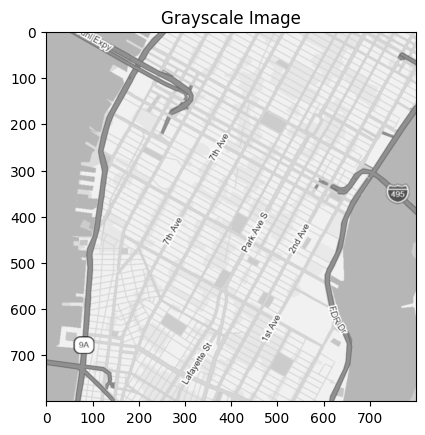

In [56]:
ImageAnalyzer.print_alignment_percentage(
    percentile,
    centers,
    tolerance_deg
)

print(f"which give the city an organic score of {100 - percentile:.2f}")

ImageAnalyzer.plot_image(img)